# Big Data rendu - AMMAR

## Chargement

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/dvf_78.csv.gz", compression="gzip", parse_dates=["date_mutation"])
print(df.shape)
df.head()

(54134, 40)


,id_mutation,date_mutation,numero_disposition,nature_mutation,valeur_fonciere,adresse_numero,adresse_suffixe,adresse_nom_voie,adresse_code_voie,code_postal,...,type_local,surface_reelle_bati,nombre_pieces_principales,code_nature_culture,nature_culture,code_nature_culture_speciale,nature_culture_speciale,surface_terrain,longitude,latitude
0,2025-1005318,2025-01-02,1,Vente,15000.0,45.0,NaN,RUE PIERRE CURIE,0550,78370.0,...,Dépendance,NaN,0.0,NaN,NaN,NaN,NaN,NaN,1.976941,48.804096
1,2025-1005319,2025-01-03,1,Vente,304000.0,16.0,NaN,RUE ROUGE,2340,78990.0,...,Maison,99.0,5.0,S,sols,NaN,NaN,154.0,1.956081,48.774913
2,2025-1005320,2025-01-02,1,Vente,165300.0,9001.0,NaN,LA CROIX BLANCHE,B015,78390.0,...,Dépendance,NaN,0.0,NaN,NaN,NaN,NaN,NaN,2.019029,48.799756
3,2025-1005320,2025-01-02,1,Vente,165300.0,8.0,NaN,AV AMBROISE PARE,0025,78390.0,...,Dépendance,NaN,0.0,NaN,NaN,NaN,NaN,NaN,2.019029,48.799756
4,2025-1005320,2025-01-02,1,Vente,165300.0,8.0,NaN,AV AMBROISE PARE,0025,78390.0,...,Appartement,65.0,3.0,NaN,NaN,NaN,NaN,NaN,2.019029,48.799756


## Traitement

In [9]:
cols = ["date_mutation", "nature_mutation", "valeur_fonciere", "nom_commune", "code_postal",
        "type_local", "surface_reelle_bati", "nombre_pieces_principales", "longitude", "latitude"]
df = df[cols]

df = df[df["nature_mutation"] == "Vente"]
df = df[df["type_local"].isin(["Maison", "Appartement"])]

df = df.drop_duplicates()
df = df.dropna(subset=["valeur_fonciere", "surface_reelle_bati"])
df = df[(df["valeur_fonciere"] > 0) & (df["surface_reelle_bati"] > 0)]

df["prix_m2"] = (df["valeur_fonciere"] / df["surface_reelle_bati"]).round(2)
df = df[df["prix_m2"].between(df["prix_m2"].quantile(0.01), df["prix_m2"].quantile(0.99))]

print(df.shape)
df.head()

(16126, 11)


,date_mutation,nature_mutation,valeur_fonciere,nom_commune,code_postal,type_local,surface_reelle_bati,nombre_pieces_principales,longitude,latitude,prix_m2
1,2025-01-03,Vente,304000.0,Élancourt,78990.0,Maison,99.0,5.0,1.956081,48.774913,3070.71
4,2025-01-02,Vente,165300.0,Bois-d'Arcy,78390.0,Appartement,65.0,3.0,2.019029,48.799756,2543.08
7,2025-01-06,Vente,210000.0,Montigny-le-Bretonneux,78180.0,Appartement,51.0,2.0,2.037769,48.773776,4117.65
11,2025-01-06,Vente,990650.0,Sonchamp,78120.0,Maison,312.0,6.0,1.906290,48.572459,3175.16
22,2025-01-06,Vente,990650.0,Sonchamp,78120.0,Maison,84.0,3.0,1.907317,48.571603,11793.45


In [10]:
df[["valeur_fonciere", "surface_reelle_bati", "prix_m2", "nombre_pieces_principales"]].describe()

,valeur_fonciere,surface_reelle_bati,prix_m2,nombre_pieces_principales
count,1.612600e+04,16126.000000,16126.000000,16126.000000
mean,3.943886e+05,84.093452,5053.174630,3.699119
std,4.213317e+05,44.658399,5484.112544,1.619113
min,2.200000e+04,6.000000,1114.860000,0.000000
25%,2.000000e+05,55.000000,3028.767500,3.000000
50%,2.950000e+05,75.000000,3953.710000,4.000000
75%,4.474950e+05,103.000000,5316.127500,5.000000
max,9.010402e+06,625.000000,72973.330000,16.000000


In [11]:
df[["surface_reelle_bati", "valeur_fonciere", "prix_m2", "nombre_pieces_principales"]].corr()

,surface_reelle_bati,valeur_fonciere,prix_m2,nombre_pieces_principales
surface_reelle_bati,1.000000,0.442999,-0.124748,0.844988
valeur_fonciere,0.442999,1.000000,0.701726,0.361628
prix_m2,-0.124748,0.701726,1.000000,-0.131412
nombre_pieces_principales,0.844988,0.361628,-0.131412,1.000000


In [12]:
top_communes = df["nom_commune"].value_counts().head(10).index
prix_par_commune = (
    df[df["nom_commune"].isin(top_communes)]
    .groupby("nom_commune")["prix_m2"]
    .mean()
    .sort_values(ascending=False)
)
prix_par_commune

nom_commune
Versailles                  8163.679066
Saint-Germain-en-Laye       7573.954747
Chatou                      6186.951432
Houilles                    5274.861169
Sartrouville                5082.886623
Poissy                      4536.764731
Conflans-Sainte-Honorine    4064.810226
Rambouillet                 3897.013324
Plaisir                     3525.236412
Élancourt                   3058.969022
Name: prix_m2, dtype: float64

## Visualisation

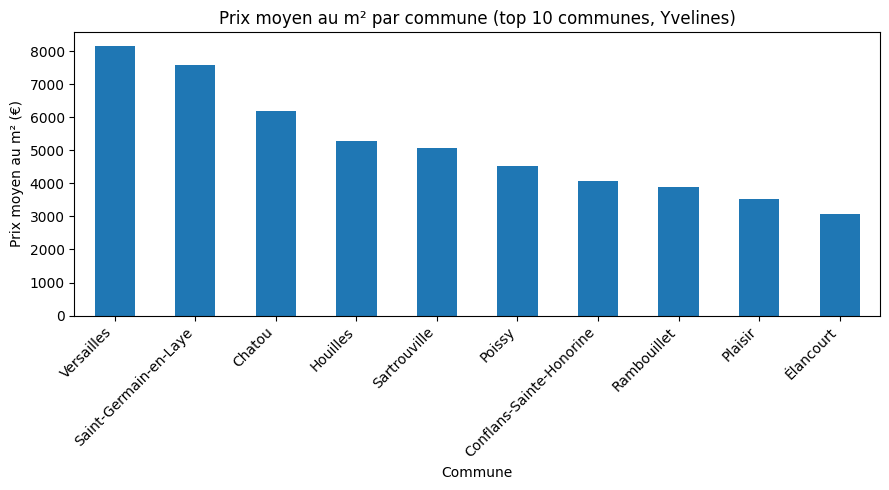

In [14]:
fig, ax = plt.subplots(figsize=(9, 5))
prix_par_commune.plot(kind="bar", ax=ax)
ax.set_title("Prix moyen au m² par commune (top 10 communes, Yvelines)")
ax.set_xlabel("Commune")
ax.set_ylabel("Prix moyen au m² (€)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("../screen/prix_m2_par_commune.png", dpi=150)
plt.show()